# Clustering without dimensionality reduction on sampled data using Method 9

## Min bins, polar stereographic projection, geo and depth bins, 20 year separation

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap
import plotly.graph_objs as go
from collections import defaultdict
import plotly.express as px
import random
from sklearn.mixture import GaussianMixture

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [3]:
# Break into two parts (1980-2000 and 2000-2023)
df_80_00 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 2000)]
df_00_23 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2023)]

In [4]:
#min bins
flag = True

In [5]:
# Sample bins of bins (geographical and depth bins) in projection space
def sample_bins_of_bins_proj(df, n_x_bins=100, n_y_bins=100, n_depth_bins=5, projection='npstere', min_flag=True):
    # Define minimum latitude for projection
    lat_min = df['Latitude_[deg_N]'].min()

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')(lon_vals, lat_vals)

    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    # xy bins in projection space
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # depth bins in original depth space
    depth_bins = np.linspace(df['Depth_[m]'].min(), df['Depth_[m]'].max(), n_depth_bins + 1)

    # Assign each point to a bin
    df['x_bin'] = pd.cut(x_vals, bins=x_bins, labels=False, include_lowest=True)
    df['y_bin'] = pd.cut(y_vals, bins=y_bins, labels=False, include_lowest=True)  
    df['depth_bin'] = pd.cut(df['Depth_[m]'], bins=depth_bins, labels=False, include_lowest=True)
    
    # Find bin with least data points and sample that many points from each bin
    if min_flag:
        min_count = df.groupby(['x_bin', 'y_bin', 'depth_bin']).size().min()
        sampled_df = df.groupby(['x_bin', 'y_bin', 'depth_bin']).apply(lambda x: x.sample(min_count, random_state=22)).reset_index(drop=True)
    else:
        avg_count = df.groupby(['x_bin', 'y_bin', 'depth_bin']).size().mean().round().astype(int)
        sampled_df = (df.groupby(['x_bin', 'y_bin', 'depth_bin'], group_keys=False).apply(lambda g: g.sample(n=min(len(g), avg_count), random_state=22)).reset_index(drop=True))
    return sampled_df

In [6]:
df_sampled_0 = sample_bins_of_bins_proj(df_80_00, projection='npstere', min_flag=flag)
df_sampled_1 = sample_bins_of_bins_proj(df_00_23, projection='npstere', min_flag=flag)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_21496/3865529425.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['x_bin'] = pd.cut(x_vals, bins=x_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_21496/3865529425.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['y_bin'] = pd.cut(y_vals, bins=y_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_21496/3865529425.py:24: SettingWithCopyWa

In [7]:
def profileNo_vs_xy_bins(
    df: pd.DataFrame,
    n_x_bins: int = 100,
    n_y_bins: int = 100,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95,
    projection: str = 'npstere'
) -> None:
    """
    Plot the number of profiles in each bin using polar stereographic projection.
    Args:
        df (pd.DataFrame): The dataset to plot.
        n_x_bins (int): Number of bins in the x direction. Defaults to 100.
        n_y_bins (int): Number of bins in the y direction. Defaults to 100.
        show_threshold (bool, optional): Whether to show the threshold marker. Defaults to False.
        threshold_quantile (float, optional): The quantile value for threshold calculation. Defaults to 0.95.
        projection (str, optional): Basemap projection string. Defaults to 'npstere'.
    Returns:
        None
    """
    # Set up the polar stereographic projection
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')

    # Reproject lat/lon to x/y (projection coordinates in metres)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Digitize points into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Flatten to get non-zero bin counts (matching original behaviour of only counting occupied bins)
    g_len = H[H > 0].flatten().tolist()
    g_len_sorted = sorted(g_len)

    # Threshold / transition point detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    # Build Plotly traces
    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

    return g_len_sorted[transition_point]

In [8]:
_ = profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [9]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=False, threshold_quantile=0.99, projection='npstere')

25

In [11]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [12]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

## Four clusters to compare methods

In [13]:
# Four clusters for comparison of methods
n_clusters = 4

In [14]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [15]:
df_sampled['gmm_label_4'] = labels

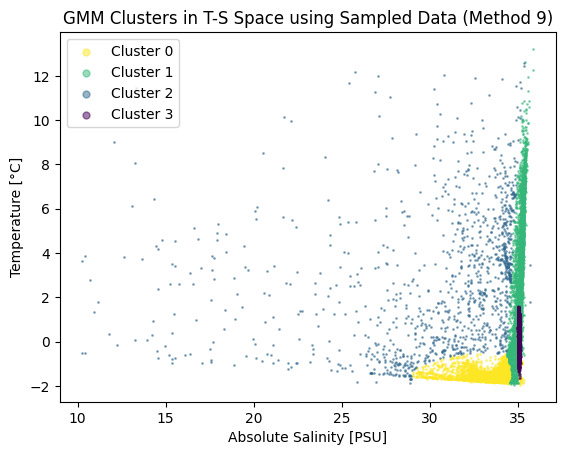

In [16]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 9)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [17]:
def plot_geo(df, n_clusters=4):
    # Compute data centroid (mean location)
    center_lat = df['Latitude_[deg_N]'].mean()
    center_lon = df['Longitude_[deg_E]'].mean()

    colors = px.colors.sample_colorscale(
        px.colors.sequential.Plasma,
        np.linspace(0, 1, n_clusters)
    )

    # Stepped colorscale
    discrete_colorscale = []
    for i, c in enumerate(colors):
        discrete_colorscale.append([i / n_clusters, c])
        discrete_colorscale.append([(i + 1) / n_clusters, c])

    fig = px.scatter_geo(
        df,
        lat='Latitude_[deg_N]',
        lon='Longitude_[deg_E]',
        color='gmm_label_4',
        color_continuous_scale=discrete_colorscale,
        range_color=(0, n_clusters),
        title="GMM clusters using sampled TS on Geographic Map"
    )

    fig.update_traces(
        marker=dict(size=5, opacity=0.9)
    )
    fig.update_coloraxes(showscale=False)

    for i, c in enumerate(colors):
        fig.add_trace(
            go.Scattergeo(
                lat=[None], lon=[None],
                mode="markers",
                marker=dict(size=8, color=c),
                name=f"Cluster {i}",
                showlegend=True
            )
        )

    fig.update_geos(
        projection_type="orthographic",
        projection_rotation=dict(lat=center_lat, lon=center_lon),
        showcoastlines=True,
        showcountries=True
    )

    fig.update_layout(
        height=800,
        width=800,
        legend_title_text="GMM Cluster",
        legend_traceorder="normal"
    )

    return fig

In [18]:
# Sample geographically for better plotting
df_sampled_plot = df_sampled.sample(n=100000, random_state=seed)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
plot_geo(df_sampled_plot, n_clusters=4)

In [19]:
#Plot in 3D
colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma,
    np.linspace(0, 1, n_clusters)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / n_clusters, c])
    discrete_colorscale.append([(i + 1) / n_clusters, c])

fig_3d = px.scatter_3d(
    df_sampled,
    x='Latitude_[deg_N]',
    y='Longitude_[deg_E]',
    z='Depth_[m]',
    color='gmm_label_4',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, n_clusters),
    title="3D Scatter Lat-Lon-Depth plot of GMM clusters"
)

fig_3d.update_traces(
    marker=dict(
        size=5
    )
)

fig_3d.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig_3d.add_trace(
        go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig_3d.update_layout(
    scene=dict(
        xaxis_title='Latitude',
        yaxis_title='Longitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')
    ),
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig_3d.show()

## Distribution

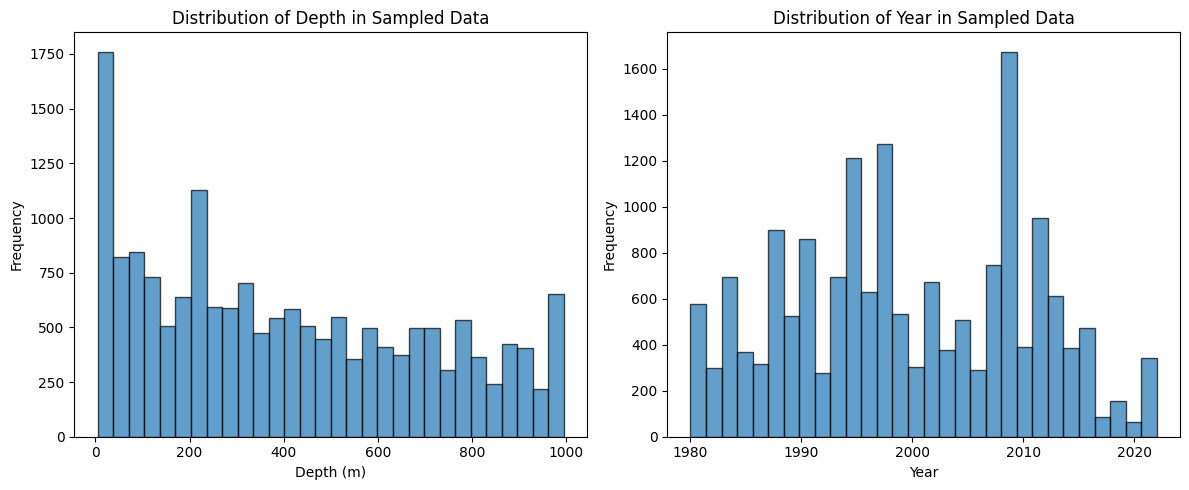

In [20]:
# Plot distribution of depth and temporal coverage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_sampled['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 2, 2)
plt.hist(df_sampled['year'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.tight_layout()
plt.show()

In [21]:
def plot_heatmap_npts_xy(ds_cleaned, n_x_bins=100, n_y_bins=100, bin_max=None, projection='npstere', projection_name='Polar Stereographic'):
    lat_min = ds_cleaned['Latitude_[deg_N]'].min()
    resolution = 'l'

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution=resolution)

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    # Reproject lat/lon to x/y
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Grid to store max depth
    H = np.zeros((n_x_bins, n_y_bins))

    # Digitize into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of points in each bin
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_bins, y_bins)

    # Colormap
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    # Plot heatmap
    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Draw bin grid (in xy space)
    for xb in x_bins:
        plt.plot([xb]*len(y_bins), y_bins, color='grey', linewidth=0.05, zorder=3)
    for yb in y_bins:
        plt.plot(x_bins, [yb]*len(x_bins), color='grey', linewidth=0.05, zorder=3)

    # Plot coastlines on top
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points per bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin in '+ f'({projection_name} Projection)')

    plt.show()

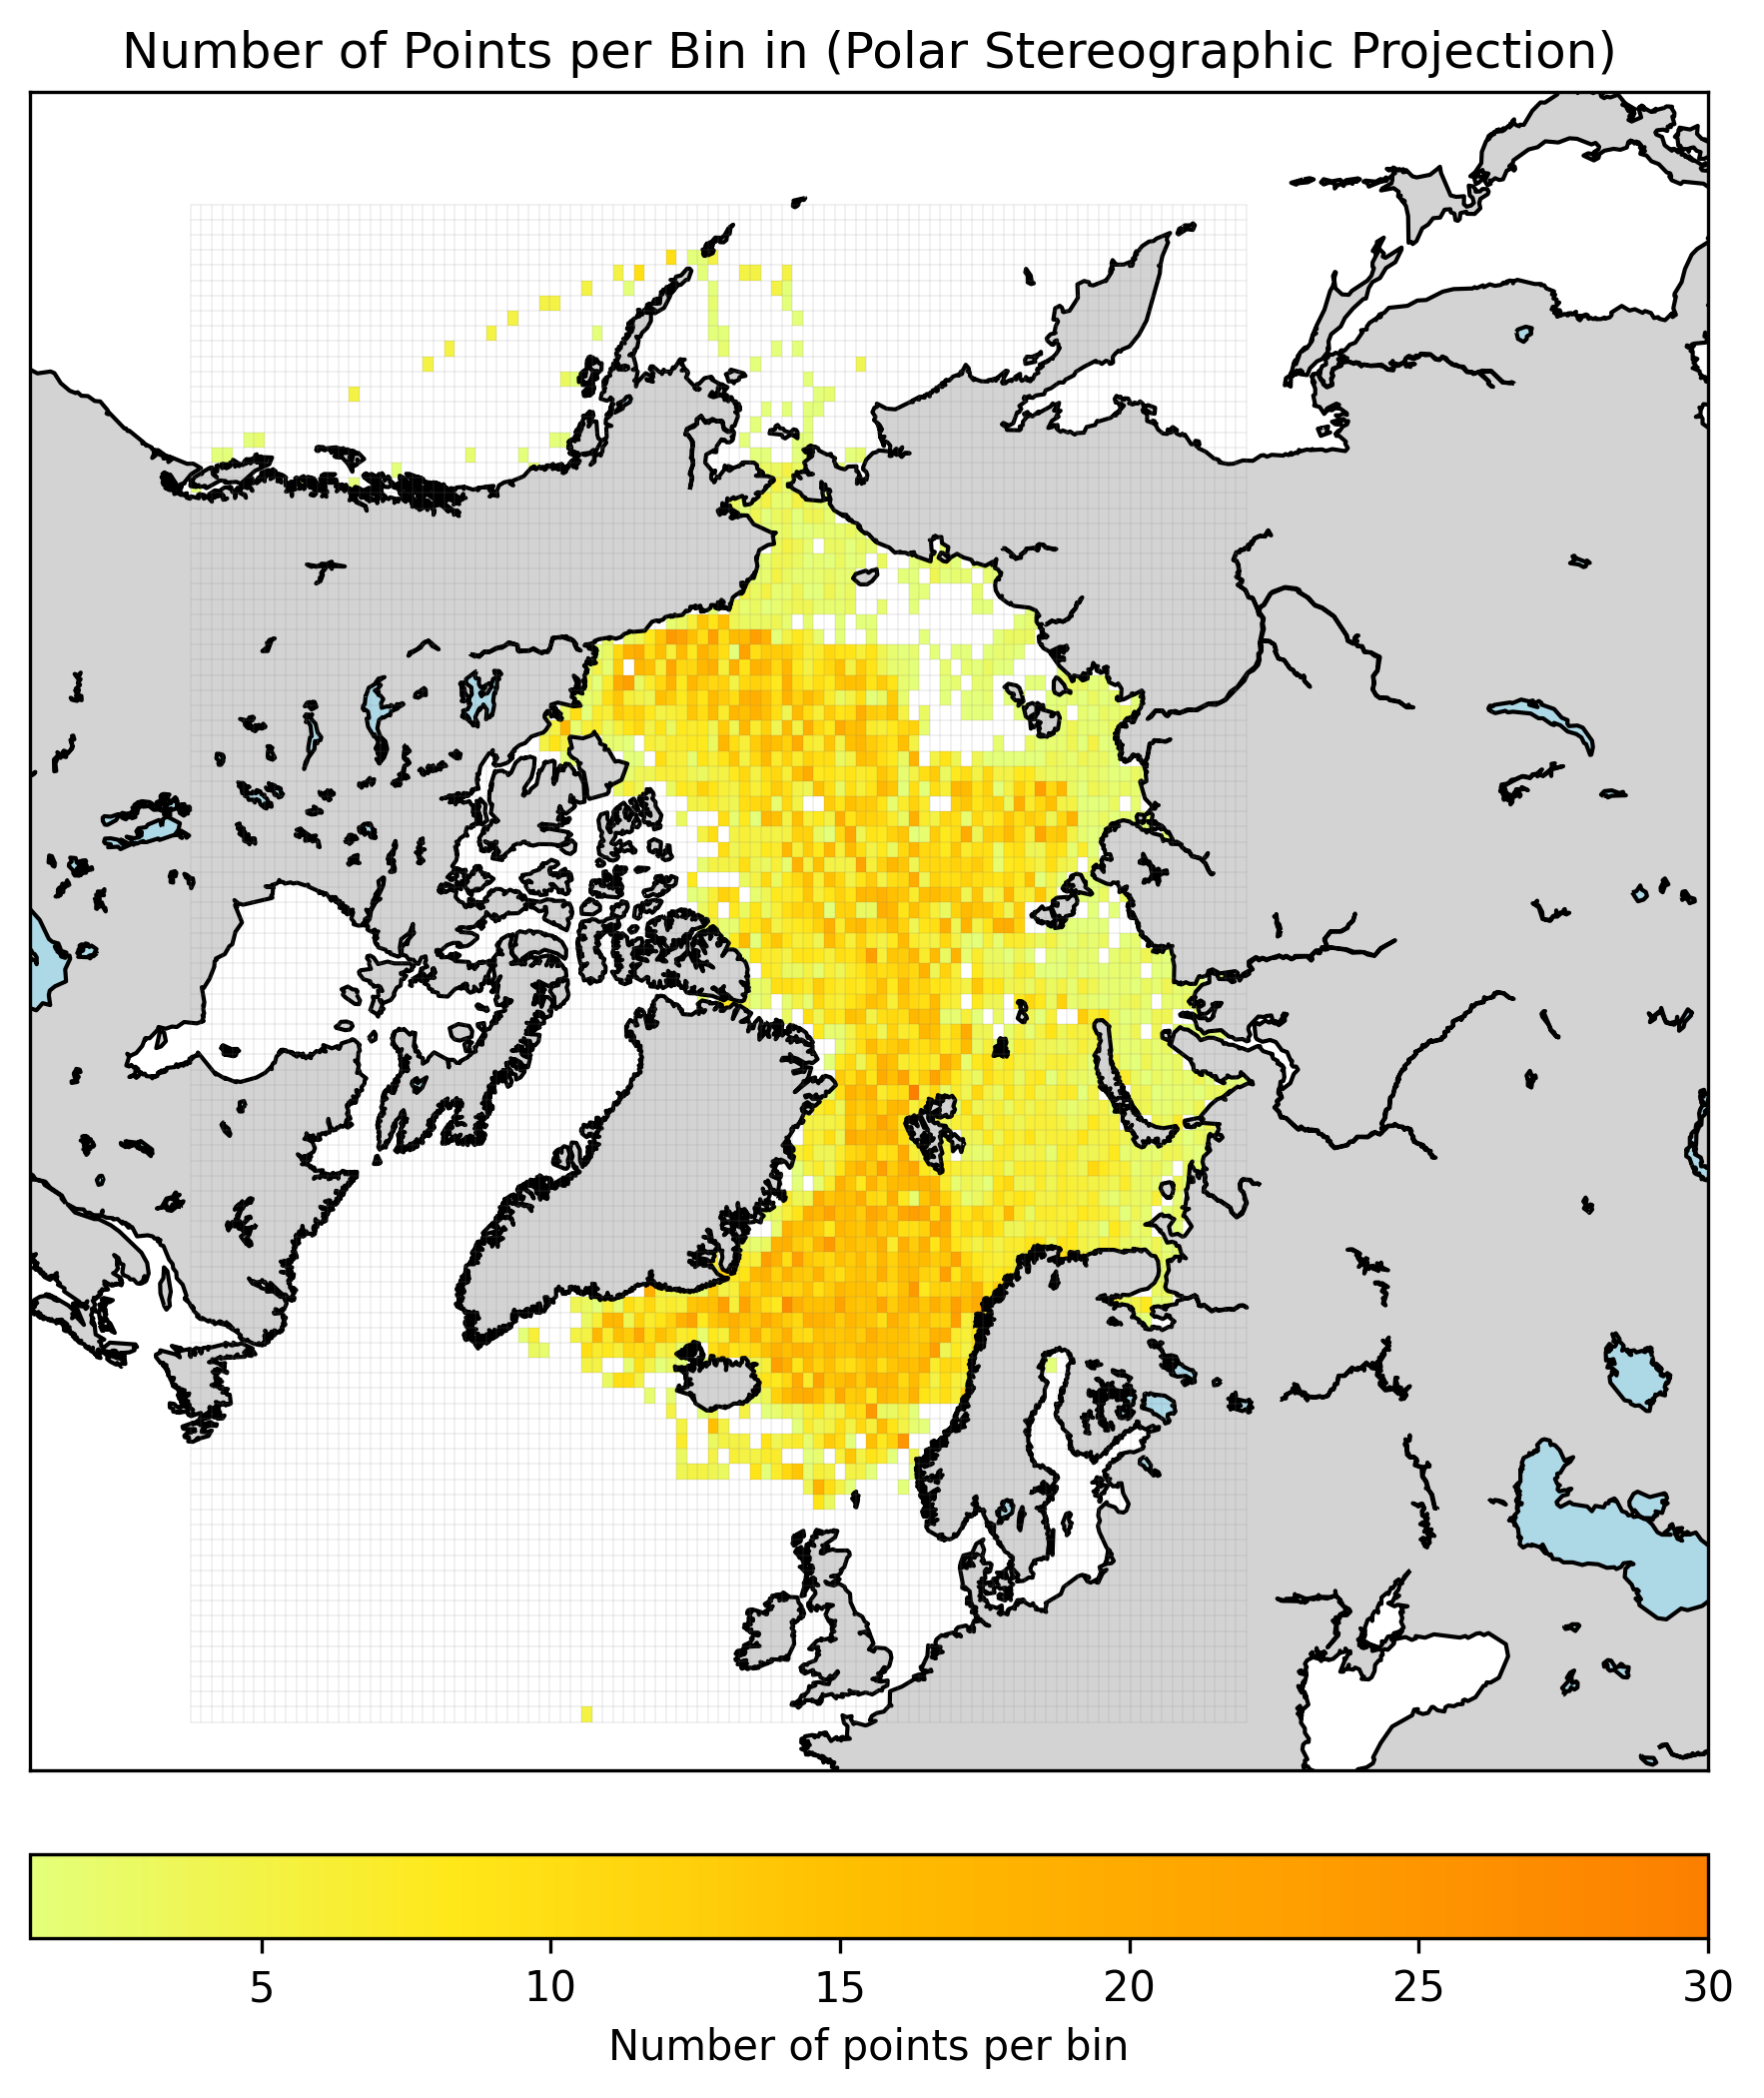

In [22]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

## BIC score

In [ ]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

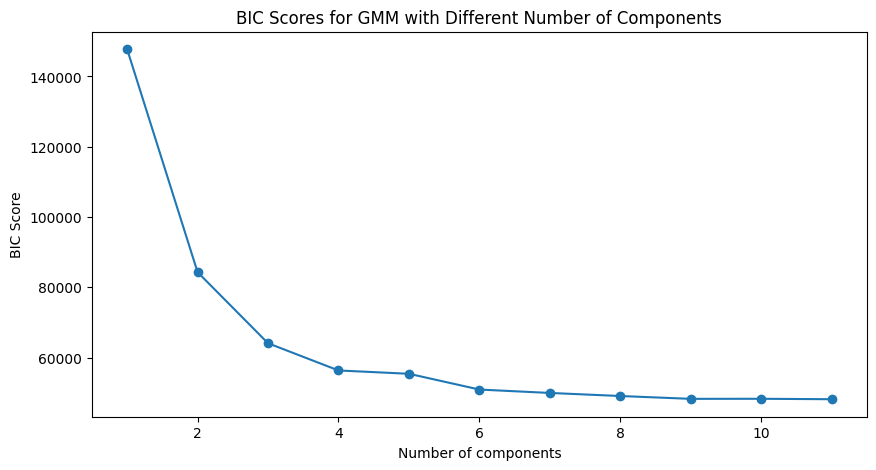

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [ ]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [ ]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [ ]:
df_sampled['gmm_label'] = labels

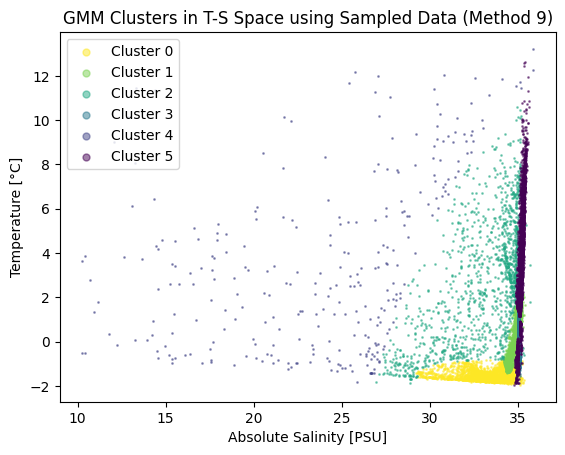

In [ ]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 9)")
plt.legend(loc='upper left', markerscale=5)
plt.show()